# Module 04B — Live Hurst Signal

This notebook builds only causal Hurst features that are allowed in the final strategy.

Working confirmation: smoothed Hurst < 0.5 and local Hurst slope crosses from >= 0 to < 0. Acceleration is not used live.

The strategy module will later combine this with 1 <= |Z| < 2 and DTE = 2HL.

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


from src.Hurst_signal import build_live_hurst_features

In [2]:
eligible_pairs = pd.read_parquet("data/processed/selected_pairs.parquet")
with open("data/processed/spreads.pkl", "rb") as f:
    spreads = pickle.load(f)

eligible_pairs.head()

,pair,dependent,independent,mean,std,min spread,max spread,theta,half_life,expected_convergence,...,stock1_has_options,stock2_has_options,stock1_num_expirations,stock2_num_expirations,stock1_first_expiration,stock2_first_expiration,stock1_last_expiration,stock2_last_expiration,eligible,exclusion_reason
0,V-MA,V,MA,-4.110665e-15,0.024864,-0.067772,0.081673,0.039095,17.729867,53.189602,...,True,True,18,16,2026-08-21,2026-08-21,2028-12-15,2028-12-15,True,None
1,MLM-VMC,MLM,VMC,1.383114e-14,0.049987,-0.182892,0.273007,0.038179,18.155329,54.465986,...,True,True,6,4,2026-08-21,2026-08-21,2027-12-17,2027-02-19,True,None
2,HLT-AXP,HLT,AXP,-2.222718e-15,0.068528,-0.268255,0.190885,0.035402,19.579342,58.738026,...,True,True,12,17,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None
3,SHW-HD,SHW,HD,-1.124588e-14,0.056705,-0.156361,0.178546,0.034308,20.203513,60.610538,...,True,True,7,17,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None
4,URI-MS,URI,MS,-4.401002e-15,0.087648,-0.277321,0.274505,0.033124,20.925609,62.776828,...,True,True,12,16,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None


In [3]:
HURST_WINDOW=120
HURST_MIN_LAG=2
HURST_MAX_LAG=40
EMA_SPAN=10
SLOPE_WINDOW=10
MAX_HURST=0.5

In [4]:
row=eligible_pairs.iloc[0]
pair=row["pair"]; dep=row["dependent"]; indep=row["independent"]
spread=spreads[(dep,indep)]
live_features=build_live_hurst_features(spread,HURST_WINDOW,HURST_MIN_LAG,HURST_MAX_LAG,EMA_SPAN,SLOPE_WINDOW,MAX_HURST)
live_features.tail()

,spread,hurst,hurst_smooth,hurst_slope,hurst_slope_negative_cross,hurst_entry_confirmation
Date,,,,,,
2022-12-20,-0.020713,0.214350,0.193351,0.004705,False,False
2022-12-21,-0.019956,0.220811,0.198344,0.005298,False,False
2022-12-22,-0.018877,0.224386,0.203079,0.005803,False,False
2022-12-23,-0.019921,0.227341,0.207490,0.006012,False,False
2022-12-27,-0.023546,0.232052,0.211956,0.005850,False,False


In [5]:
live_features[live_features["hurst_entry_confirmation"]].tail(20)

,spread,hurst,hurst_smooth,hurst_slope,hurst_slope_negative_cross,hurst_entry_confirmation
Date,,,,,,
2019-12-30,-0.005413,0.302792,0.301631,-0.000284,True,True
2020-01-16,0.003364,0.298438,0.307008,-0.001052,True,True
2020-02-04,-0.005167,0.276278,0.303571,-0.000180,True,True
2020-03-05,0.009088,0.215976,0.225685,-0.000069,True,True
2020-06-17,0.009637,0.204993,0.206523,-0.000129,True,True
2020-07-15,0.018837,0.203648,0.212848,-0.001472,True,True
2020-09-28,-0.040773,0.431998,0.438231,-0.000310,True,True
2020-12-17,0.016091,0.497052,0.497061,-0.000278,True,True
2021-02-10,-0.001284,0.488267,0.489118,-0.000712,True,True


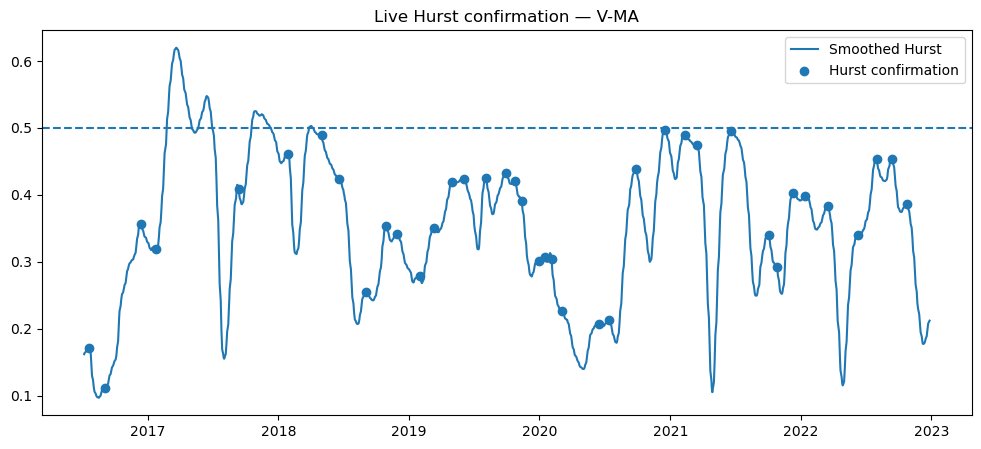

In [6]:
plt.figure(figsize=(12,5))
plt.plot(live_features.index,live_features["hurst_smooth"],label="Smoothed Hurst")
plt.axhline(0.5,linestyle="--")
confirmed=live_features[live_features["hurst_entry_confirmation"]]
plt.scatter(confirmed.index,confirmed["hurst_smooth"],label="Hurst confirmation")
plt.title(f"Live Hurst confirmation — {pair}")
plt.legend()
plt.show()

In [10]:
live_frames=[]
for _,row in eligible_pairs.iterrows():
    pair=row["pair"]; dep=row["dependent"]; indep=row["independent"]; key=(dep,indep)
    if key not in spreads: continue
    f = build_live_hurst_features(spreads[key],HURST_WINDOW,HURST_MIN_LAG,HURST_MAX_LAG,EMA_SPAN,SLOPE_WINDOW,MAX_HURST)
    f = f.reset_index()
    f = f.rename(columns={f.columns[0]: "date"})
    f["pair"] = pair
    f["dependent"] = dep
    f["independent"] = indep
    live_frames.append(f)

hurst_live_panel=pd.concat(live_frames,ignore_index=True).sort_values(["date","pair"]).reset_index(drop=True)
hurst_live_panel.head()

,date,spread,hurst,hurst_smooth,hurst_slope,hurst_slope_negative_cross,hurst_entry_confirmation,pair,dependent,independent
0,2016-01-04,-0.082721,NaN,NaN,NaN,False,False,ADI-CDW,ADI,CDW
1,2016-01-04,-0.078790,NaN,NaN,NaN,False,False,CDW-KEYS,CDW,KEYS
2,2016-01-04,-0.108674,NaN,NaN,NaN,False,False,DUK-KO,DUK,KO
3,2016-01-04,-0.026586,NaN,NaN,NaN,False,False,FANG-EOG,FANG,EOG
4,2016-01-04,-0.147175,NaN,NaN,NaN,False,False,HLT-AXP,HLT,AXP


In [11]:
hurst_live_panel.to_parquet("data/processed/hurst_live_features.parquet",index=False)
print("Saved causal Hurst feature panel.")

Saved causal Hurst feature panel.
